<a href="https://colab.research.google.com/github/NamrathaBajjuri/AIML-TRAINING-TNSIF/blob/main/RANDOM_FOREST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RANDOM FOREST**

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Create Dataset
data = {
    "Study_Hours": [2, 4, 6, 8, 3, 5, 7, 9, 1, 10],
    "Attendance": [60, 70, 80, 90, 65, 75, 85, 95, 50, 98],
    "Assignments": [1, 2, 3, 4, 1, 2, 3, 4, 0, 5],
    "Result": ["Fail", "Fail", "Pass", "Pass", "Fail",
               "Pass", "Pass", "Pass", "Fail", "Pass"]
}

df = pd.DataFrame(data)

print(df)

   Study_Hours  Attendance  Assignments Result
0            2          60            1   Fail
1            4          70            2   Fail
2            6          80            3   Pass
3            8          90            4   Pass
4            3          65            1   Fail
5            5          75            2   Pass
6            7          85            3   Pass
7            9          95            4   Pass
8            1          50            0   Fail
9           10          98            5   Pass


In [3]:
#Convert Target Variable into Numbers
df["Result"] = df["Result"].map({"Fail": 0, "Pass": 1})

In [4]:
#Define Features and Target
X = df[["Study_Hours", "Attendance", "Assignments"]]
y = df["Result"]

In [5]:
#Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#Train the Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
#Make Predictions
y_pred = model.predict(X_test)

print("Predictions:", y_pred)

Predictions: [0 0]


In [8]:
#Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix
[[2]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [9]:
#Predict for a New Student
new_student = [[6, 82, 3]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

Prediction: Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


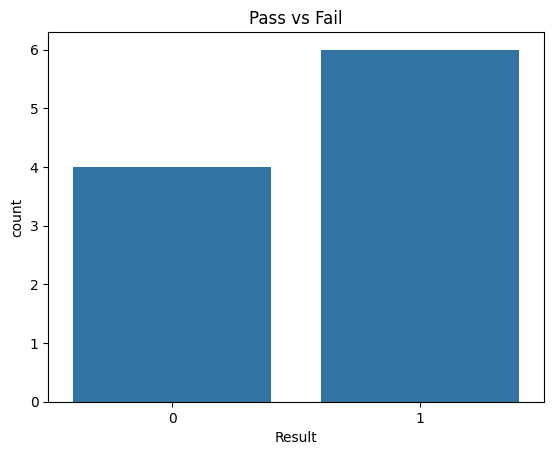

In [10]:
# Count Plot
sns.countplot(x="Result", data=df)
plt.title("Pass vs Fail")
plt.show()

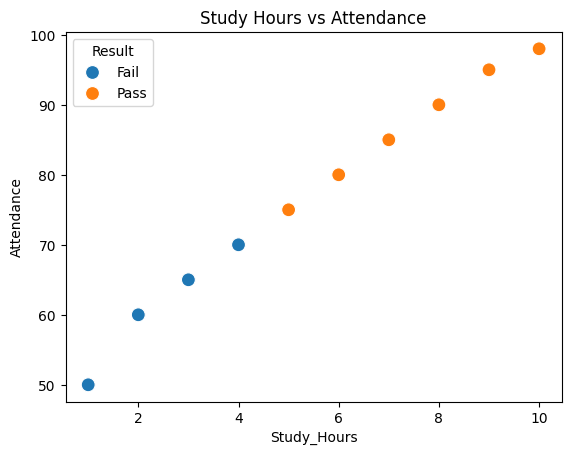

In [11]:
#Scatter Plot
df["Result"] = df["Result"].map({0:"Fail", 1:"Pass"})

sns.scatterplot(
    x="Study_Hours",
    y="Attendance",
    hue="Result",
    data=df,
    s=100
)

plt.title("Study Hours vs Attendance")
plt.show()

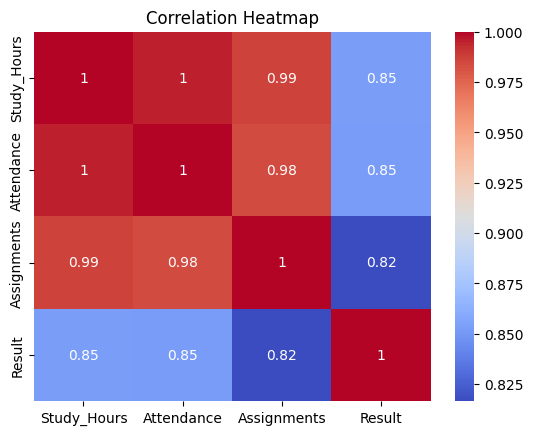

In [12]:
# Correlation Heatmap
df["Result"] = df["Result"].map({"Fail":0, "Pass":1})

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()